# Titanic Survival Classification

Task: clean and pre-process the Titanic dataset, train a classification model to predict survival, and evaluate its performance.

**Dataset:** Kaggle Titanic (`train.csv`, `test.csv`, `gender_submission.csv`)


## 1. Imports and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Initial Inspection

In [2]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
train.describe(include='all')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [4]:
print("Missing values in train:")
print(train.isnull().sum())
print()
print("Missing values in test:")
print(test.isnull().sum())


Missing values in train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


## 3. Data Cleaning & Preprocessing

Steps:
- Fill missing `Age` with the median age *within each Pclass/Sex group* (more accurate than a single global median).
- Fill missing `Embarked` with the mode.
- Fill missing `Fare` (test set) with the median fare for that Pclass.
- Drop `Cabin` (too many missing values), `Ticket`, `Name`, `PassengerId` (not predictive in raw form) — but first engineer a `Title` feature from `Name` and a `FamilySize` feature from `SibSp`/`Parch`.
- Encode categorical variables (`Sex`, `Embarked`, `Title`).


In [5]:
def engineer_features(df):
    df = df.copy()

    # Title from Name
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
                   'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Family size and IsAlone
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    return df

train_fe = engineer_features(train)
test_fe = engineer_features(test)

train_fe[['Name', 'Title', 'FamilySize', 'IsAlone']].head()


,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


In [6]:
def fill_missing(df, age_lookup):
    df = df.copy()
    # Age: median per Pclass/Sex group
    df['Age'] = df.apply(
        lambda r: age_lookup.get((r['Pclass'], r['Sex']), df['Age'].median())
        if pd.isnull(r['Age']) else r['Age'],
        axis=1
    )
    # Embarked: mode
    if df['Embarked'].isnull().any():
        df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    # Fare: median per Pclass
    if df['Fare'].isnull().any():
        df['Fare'] = df.apply(
            lambda r: df.groupby('Pclass')['Fare'].median()[r['Pclass']]
            if pd.isnull(r['Fare']) else r['Fare'],
            axis=1
        )
    return df

age_lookup = train_fe.groupby(['Pclass', 'Sex'])['Age'].median().to_dict()

train_clean = fill_missing(train_fe, age_lookup)
test_clean = fill_missing(test_fe, age_lookup)

print("Remaining missing values (train):")
print(train_clean[['Age', 'Embarked', 'Fare']].isnull().sum())


Remaining missing values (train):
Age         0
Embarked    0
Fare        0
dtype: int64


In [7]:
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']

train_model = train_clean.drop(columns=drop_cols)
test_model = test_clean.drop(columns=[c for c in drop_cols if c != 'PassengerId'])
test_ids = test_clean['PassengerId']

# One-hot encode categoricals
cat_cols = ['Sex', 'Embarked', 'Title']
train_model = pd.get_dummies(train_model, columns=cat_cols, drop_first=True)
test_model = pd.get_dummies(test_model, columns=cat_cols, drop_first=True)

# Align columns between train/test (test may lack a rare Title category)
test_model = test_model.reindex(columns=train_model.drop(columns=['Survived']).columns, fill_value=0)

train_model.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,0,3,22.0,1,0,7.2500,2,0,True,False,True,False,True,False,False,False
1,1,1,38.0,1,0,71.2833,2,0,False,False,False,False,False,True,False,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,True,True,False,False,False,False
3,1,1,35.0,1,0,53.1000,2,0,False,False,True,False,False,True,False,False
4,0,3,35.0,0,0,8.0500,1,1,True,False,True,False,True,False,False,False


## 4. Exploratory Checks (post-cleaning sanity)

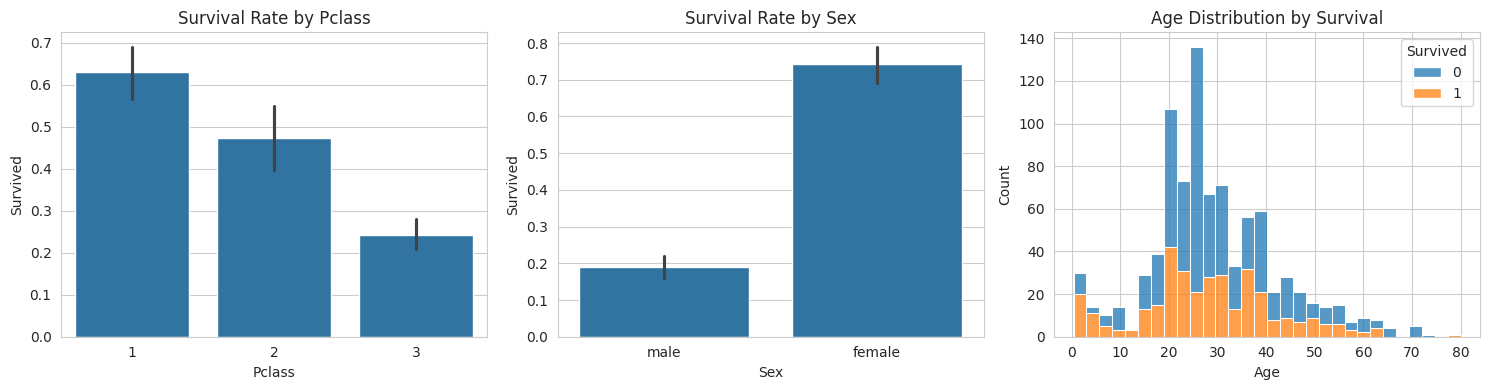

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(x='Pclass', y='Survived', data=train_clean, ax=axes[0])
axes[0].set_title('Survival Rate by Pclass')

sns.barplot(x='Sex', y='Survived', data=train_clean, ax=axes[1])
axes[1].set_title('Survival Rate by Sex')

sns.histplot(data=train_clean, x='Age', hue='Survived', multiple='stack', bins=30, ax=axes[2])
axes[2].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.show()


## 5. Train / Validation Split

In [9]:
X = train_model.drop(columns=['Survived'])
y = train_model['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train:", X_train.shape, " Val:", X_val.shape)


Train: (712, 15)  Val: (179, 15)


## 6. Model Training

Two models are trained and compared:
- Logistic Regression (baseline, interpretable)
- Random Forest (non-linear, usually stronger on this dataset)


In [10]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train, y_train)  # tree model doesn't need scaling

print("Models trained.")


Models trained.


## 7. Evaluation

In [11]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print()
    print(classification_report(y_true, y_pred))
    print()

log_pred = log_reg.predict(X_val_scaled)
log_proba = log_reg.predict_proba(X_val_scaled)[:, 1]
evaluate("Logistic Regression", y_val, log_pred, log_proba)

rf_pred = rf.predict(X_val)
rf_proba = rf.predict_proba(X_val)[:, 1]
evaluate("Random Forest", y_val, rf_pred, rf_proba)


--- Logistic Regression ---
Accuracy : 0.8547
Precision: 0.8413
Recall   : 0.7681
F1 score : 0.8030
ROC AUC  : 0.8769

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179


--- Random Forest ---
Accuracy : 0.8380
Precision: 0.8333
Recall   : 0.7246
F1 score : 0.7752
ROC AUC  : 0.8586

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       110
           1       0.83      0.72      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179




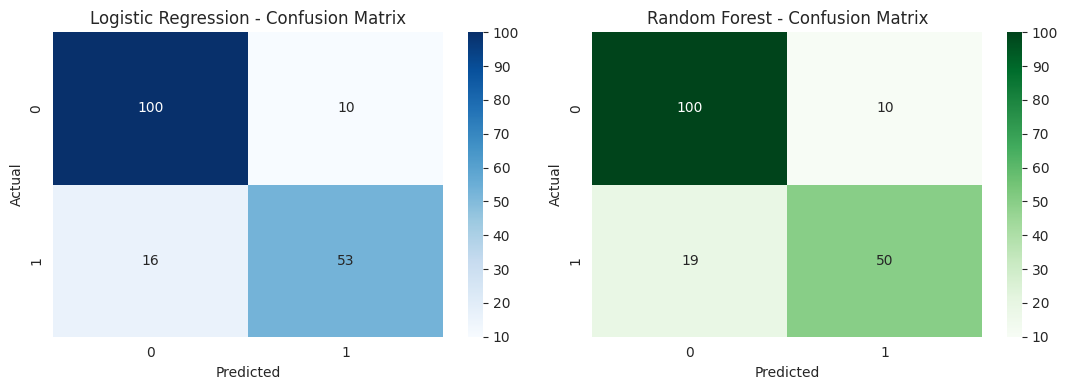

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(confusion_matrix(y_val, log_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_val, rf_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


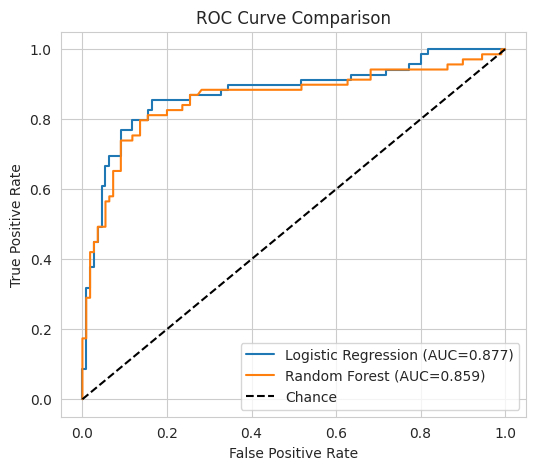

In [13]:
fpr_log, tpr_log, _ = roc_curve(y_val, log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={roc_auc_score(y_val, log_proba):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_val, rf_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


## 8. Cross-Validation (robustness check)

In [14]:
cv_log = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), scaler.fit_transform(X), y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42), X, y, cv=5, scoring='accuracy')

print(f"Logistic Regression 5-fold CV accuracy: {cv_log.mean():.4f} (+/- {cv_log.std():.4f})")
print(f"Random Forest       5-fold CV accuracy: {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")


Logistic Regression 5-fold CV accuracy: 0.8238 (+/- 0.0221)
Random Forest       5-fold CV accuracy: 0.8271 (+/- 0.0198)


## 9. Feature Importance (Random Forest)

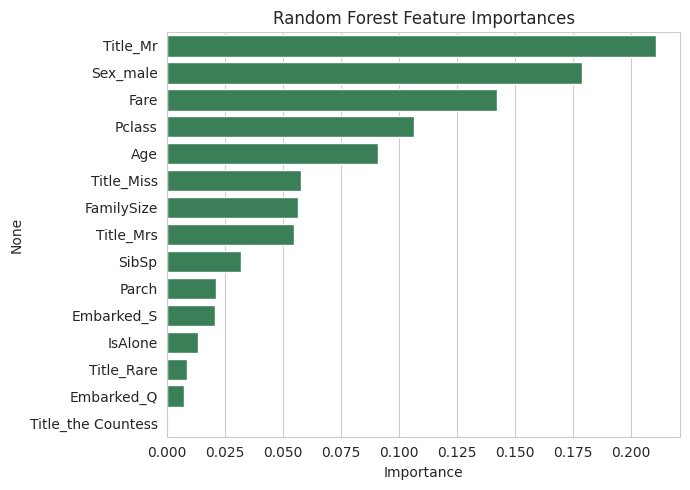

Title_Mr              0.210610
Sex_male              0.178819
Fare                  0.142224
Pclass                0.106292
Age                   0.090763
Title_Miss            0.057847
FamilySize            0.056493
Title_Mrs             0.054572
SibSp                 0.031642
Parch                 0.020903
Embarked_S            0.020763
IsAlone               0.013305
Title_Rare            0.008360
Embarked_Q            0.007406
Title_the Countess    0.000000
dtype: float64

In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, color='seagreen')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances


## 10. Final Model & Kaggle Submission

Random Forest is selected as the final model (compare CV accuracy above), refit on the full training set, then used to predict on `test.csv`.


In [16]:
final_model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
final_model.fit(X, y)

test_preds = final_model.predict(test_model)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_preds
})
submission.to_csv('submission.csv', index=False)
submission.head()


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## 11. Summary

- Missing `Age` values were imputed using Pclass/Sex group medians rather than a single global median.
- `Title` (extracted from `Name`) and `FamilySize`/`IsAlone` (from `SibSp`+`Parch`) were engineered as additional predictive features.
- Two models were compared: Logistic Regression (baseline) and Random Forest.
- Both models were evaluated on accuracy, precision, recall, F1, ROC AUC, and 5-fold cross-validation for robustness.
- The Random Forest model was retrained on the full training set and used to generate `submission.csv` in the Kaggle-required format.
